In [37]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 Carga de los datos

In [52]:
import pandas as pd

df = pd.read_excel("GSAF5 (1).xls")

In [41]:
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,18th September,2026,Unprovoked,AUSTRALIA,Western Australia,Sorrento Beach Perth,swimming,Greg O'Neil,M,63,...,Great White Shark 6m (20ft),Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16th September,2026,Unprovoked,CANADA,Quebec,Off the coast of Perce Le Bilbo dive site,diving,Unknown Male,M,?,...,Great White Shark,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,14th September,2026,Unprovoked,BAHAMAS,Bimini,Bimini Island,swimming,Unknown Austrian Tourist,F,37,...,Unknown,Kevin McMurray Trackingsharks.com: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13th September,2026,Unprovoked,AUSTRALIA,Western Australia,Geraldton,surfing,Mel Ismail,M,50's,...,Unknown,Simon De Marchi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7th September,2026,Unprovoked,USA,Hawaii,Honolulu,surfing,Wants to remain anonymous,M,24,...,Tiger Shark suspected,Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2 Variables seleccionadas

Para nuestro análisis hemos seleccionado cinco variables principales del dataset:

- `Country`: país donde se registró el ataque
- `State`: estado o región donde ocurrió
- `Year`: año del ataque
- `Activity`: actividad que estaba realizando la persona
- `Fatal Y/N`: indica si el ataque fue mortal o no

Estas variables nos permitirán estudiar la distribución geográfica de los ataques, las actividades más frecuentes, su evolución temporal y su fatalidad.

# 3 Limpieza de datos

Para mantener el notebook organizado, hemos creado un archivo externo llamado `cleaning.py`

En este archivo hemos definido diferentes funciones para limpiar y estandarizar las cinco variables seleccionadas.

La función `clean_data()` ejecuta todas las funciones de limpieza en un mismo proceso:

1. Limpieza de `Country`
2. Limpieza de `State`
3. Limpieza de `Year`
4. Limpieza de `Activity`
5. Limpieza de `Fatal Y/N`

In [51]:
%load_ext autoreload
%autoreload 2

from cleaning import clean_data


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
df = clean_data(df)

# 4 Comprobación de la limpieza

Después de aplicar las funciones de limpieza, comprobamos que las cinco variables seleccionadas tienen el formato esperado.

También revisamos los valores nulos y los tipos de datos para asegurarnos de que el DataFrame está preparado para comenzar el análisis exploratorio.

In [49]:
df[["Year", "Country", "State", "Activity", "Fatal Y/N"]].head()

,Year,Country,State,Activity,Fatal Y/N
0,2026,AUSTRALIA,Western Australia,swimming,Y
1,2026,CANADA,Quebec,diving,N
2,2026,BAHAMAS,Bimini,swimming,N
3,2026,AUSTRALIA,Western Australia,surfing,N
4,2026,USA,Hawaii,surfing,N


In [50]:
df["Activity"].value_counts().head(10)

Activity
surfing         1162
swimming        1075
unknown          588
fishing          514
spearfishing     405
wading           178
bathing          167
diving           155
snorkeling       138
standing         115
Name: count, dtype: int64

# 5 Comprobación de valores nulos

Después de aplicar la limpieza comprobamos cuántos valores nulos permanecen en cada una de las cinco variables. En las variables categóricas, los valores sin información se han identificado como `UNKNOWN`, `Unknown` o `unknown`, dependiendo del formato utilizado en cada columna.

In [54]:
variables = [
    "Year",
    "Country",
    "State",
    "Activity",
    "Fatal Y/N"
]

df[variables].isna().sum()

Year         2
Country      0
State        0
Activity     0
Fatal Y/N    0
dtype: int64

# 6 Resultado de la limpieza

Después de aplicar las funciones de limpieza, `Country`, `State`, `Activity` y `Fatal Y/N` no contienen valores nulos.

En `Year` permanecen 2 valores nulos porque no disponemos de información suficiente para determinar el año correspondiente. Hemos decidido mantenerlos como valores desconocidos en lugar de asignarles un año artificialmente.

Estos registros se excluirán únicamente cuando realicemos el análisis temporal.

# 7 Análisis Exploratorio de Datos (EDA)

Una vez finalizada la limpieza de los datos, comenzamos el análisis exploratorio.

El objetivo es utilizar las cinco variables seleccionadas para identificar patrones y responder a nuestras cuatro hipótesis o preguntas de investigación:

1. ¿Dónde se concentran los ataques registrados?
2. ¿Qué estaban haciendo las personas cuando ocurrió el ataque?
3. ¿Cómo han cambiado los ataques registrados a lo largo del tiempo?
4. ¿Qué proporción de los ataques registrados son mortales?

# 7.1 Concentración geográfica

Para estudiar la distribución geográfica de los ataques, analizamos conjuntamente las variables `Country` y `State`.

Agrupamos los registros por país y estado/región y contamos el número de ataques registrados en cada localización.

Este análisis nos permitirá comprobar si los ataques se distribuyen de forma uniforme o si se concentran en determinadas zonas geográficas.

In [55]:
attacks_by_location = (
    df.groupby(["Country", "State"])
    .size()
    .reset_index(name="Attacks")
    .sort_values("Attacks", ascending=False)
)

attacks_by_location.head(10)

,Country,State,Attacks
1025,USA,Florida,1200
21,AUSTRALIA,New South Wales,524
25,AUSTRALIA,Queensland,357
1030,USA,Hawaii,348
1017,USA,California,328
34,AUSTRALIA,Western Australia,249
874,SOUTH AFRICA,Kwazulu-Natal,219
880,SOUTH AFRICA,Western Cape Province,197
1059,USA,South Carolina,176
871,SOUTH AFRICA,Eastern Cape Province,169


# Exclusión de localizaciones desconocidas

Para interpretar correctamente los resultados geográficos, excluimos del ranking aquellos registros cuyo país o estado/región es desconocido.

Los registros no se eliminan del DataFrame original; únicamente se excluyen de este análisis concreto.

In [56]:
known_locations = attacks_by_location[
    (attacks_by_location["Country"] != "UNKNOWN") &
    (attacks_by_location["State"].str.upper() != "UNKNOWN")
]

known_locations.head(10)

,Country,State,Attacks
1025,USA,Florida,1200
21,AUSTRALIA,New South Wales,524
25,AUSTRALIA,Queensland,357
1030,USA,Hawaii,348
1017,USA,California,328
34,AUSTRALIA,Western Australia,249
874,SOUTH AFRICA,Kwazulu-Natal,219
880,SOUTH AFRICA,Western Cape Province,197
1059,USA,South Carolina,176
871,SOUTH AFRICA,Eastern Cape Province,169


In [ ]:
# Obtenemos el Top 10

top_10_locations = known_locations.head(10)

top_10_locations

,Country,State,Attacks
1025,USA,Florida,1200
21,AUSTRALIA,New South Wales,524
25,AUSTRALIA,Queensland,357
1030,USA,Hawaii,348
1017,USA,California,328
34,AUSTRALIA,Western Australia,249
874,SOUTH AFRICA,Kwazulu-Natal,219
880,SOUTH AFRICA,Western Cape Province,197
1059,USA,South Carolina,176
871,SOUTH AFRICA,Eastern Cape Province,169


# 7.1 Concentración geográfica - Conclusión

Los ataques registrados no se distribuyen de manera uniforme entre las diferentes localizaciones.

Florida (USA) destaca claramente con 1.200 ataques registrados, seguida de New South Wales (Australia) con 524. Además, entre las diez primeras posiciones aparecen repetidamente regiones de Estados Unidos, Australia y Sudáfrica.

Por tanto, los datos muestran una concentración geográfica de los ataques registrados en determinadas regiones.

Aclaración: Este análisis refleja el número de ataques presentes en el dataset y no necesariamente el riesgo real de sufrir un ataque, ya que no disponemos de información sobre el número de personas expuestas al mar en cada localización.

# 7.1 Concentración geográfica - Visualización

Representamos las diez localizaciones con mayor número de ataques registrados mediante un gráfico de barras horizontal

In [ ]:
# Instalación de la librería de visualización

%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------  9.4/9.5 MB 48.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 39.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 38.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 76.7 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 25.4 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
  

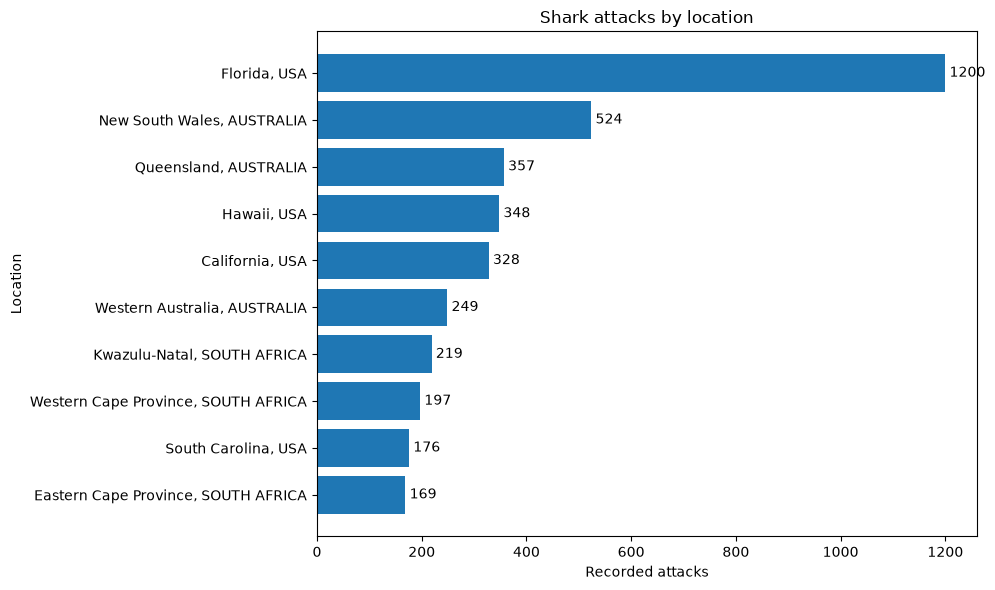

In [62]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10_plot["Location"][::-1],
    top_10_plot["Attacks"][::-1]
)

plt.xlabel("Recorded attacks")
plt.ylabel("Location")
plt.title("Shark attacks by location")

# Añadimos el número de ataques al final de cada barra
plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

# 7.1 Concentración geográfica - Comentario Final Imagen

Los ataques registrados presentan una clara concentración geográfica. Por tanto, los resultados apoyan nuestra hipótesis de que los ataques registrados no se distribuyen uniformemente entre las distintas localizaciones.

# 7.2 Actividades realizadas durante los ataques

Analizamos la variable "Activity" para identificar qué actividades aparecen con mayor frecuencia en los registros de ataques.
Para este análisis excluimos la categoría "unknown", ya que representa casos en los que no conocemos la actividad realizada.

In [63]:
activity_counts = (
    df[df["Activity"] != "unknown"]["Activity"]
    .value_counts()
    .head(10)
)

activity_counts

Activity
surfing         1162
swimming        1075
fishing          514
spearfishing     405
wading           178
bathing          167
diving           155
snorkeling       138
standing         115
scuba diving     106
Name: count, dtype: int64

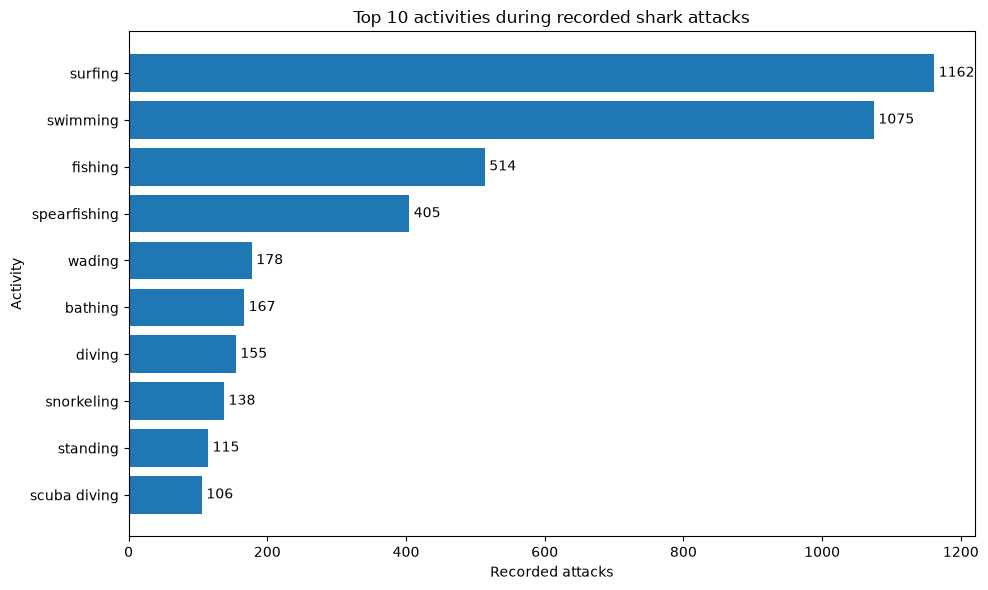

In [64]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    activity_counts.index[::-1],
    activity_counts.values[::-1]
)

plt.xlabel("Recorded attacks")
plt.ylabel("Activity")
plt.title("Top 10 activities during recorded shark attacks")

plt.bar_label(bars, padding=3)

plt.tight_layout()
plt.show()

# 7.2 Actividades realizadas durante los ataques - Visualización

A nivel global, "surfing"" es la actividad que aparece con mayor frecuencia en los ataques registrados, con 1.162 casos, seguida muy de cerca por "swimming", con 1.075

A mayor distancia aparecen "fishing" (514) y "spearfishing" (405).

Sin embargo, este resultado muestra la distribución global de las actividades. Para comprobar si este patrón también aparece en las zonas con mayor número de ataques, cruzamos "Activity" con "Country" y "State".

# 7.2 Actividades en las zonas con más ataques registrados

Para profundizar en el análisis, estudiamos las actividades más frecuentes dentro de las cinco localizaciones con mayor número de ataques registrados.

De esta forma podemos comprobar si las actividades predominantes son similares en las principales zonas geográficas o si existen diferencias entre ellas.

In [65]:
top_5_locations = known_locations.head(5)[
    ["Country", "State"]
]

top_5_locations

,Country,State
1025,USA,Florida
21,AUSTRALIA,New South Wales
25,AUSTRALIA,Queensland
1030,USA,Hawaii
1017,USA,California


#  7.2 Contamos las actividades por localización (Country + State + Activity)

In [66]:
activity_by_location = (
    df[df["Activity"] != "unknown"]
    .groupby(["Country", "State", "Activity"])
    .size()
    .reset_index(name="Attacks")
)

activity_by_location.head()

,Country,State,Activity,Attacks
0,AFRICA,Unknown,jumped into river,1
1,ALGERIA,Unknown,swimming,1
2,AMERICAN SAMOA,Tutuila Island,cleaning hull of ship,1
3,AMERICAN SAMOA,Tutuila Island,dived overboard & was swimming near stern of t...,1
4,AMERICAN SAMOA,Tutuila Island,swimming,1


In [ ]:
# Nos quedamos solo con el Top 5 geográfico

activity_top_5 = activity_by_location.merge(
    top_5_locations,
    on=["Country", "State"]
)

activity_top_5.head(10)

,Country,State,Activity,Attacks
0,AUSTRALIA,New South Wales,.,1
1,AUSTRALIA,New South Wales,"after rowing skiff was holed by shark, he was ...",1
2,AUSTRALIA,New South Wales,anti-sabotage night dive exercise alongside de...,1
3,AUSTRALIA,New South Wales,bathing,27
4,AUSTRALIA,New South Wales,bathing in 2 feet of water,1
5,AUSTRALIA,New South Wales,bathing in 5' of water,1
6,AUSTRALIA,New South Wales,bathing in knee-deep water,1
7,AUSTRALIA,New South Wales,bathing in waist-deep water,1
8,AUSTRALIA,New South Wales,bathing or body surfing,1
9,AUSTRALIA,New South Wales,boat capsized,1


In [ ]:
# Sacamos las 3 actividades principales de cada zona

activity_top_5 = activity_top_5.sort_values(
    ["Country", "State", "Attacks"],
    ascending=[True, True, False]
)

In [69]:
top_3_activities = (
    activity_top_5
    .groupby(["Country", "State"])
    .head(3)
)

top_3_activities

,Country,State,Activity,Attacks
97,AUSTRALIA,New South Wales,surfing,122
101,AUSTRALIA,New South Wales,swimming,78
38,AUSTRALIA,New South Wales,fishing,43
225,AUSTRALIA,Queensland,swimming,65
173,AUSTRALIA,Queensland,fishing,26
215,AUSTRALIA,Queensland,spearfishing,25
340,USA,California,surfing,89
343,USA,California,swimming,25
274,USA,California,fishing,20
503,USA,Florida,surfing,422


# 7.2 Actividades realizadas durante los ataques - Conclusión

Al analizar las actividades más frecuentes en las cinco zonas con mayor número de ataques registrados, observamos que "surfing" y "swimming" aparecen de forma recurrente entre las principales actividades.

El "surfing" ocupa la primera posición en New South Wales (122 casos), California (89), Florida (422) y Hawaii (76). En cambio, en "Queensland", la actividad más frecuente es "swimming" con 65 casos.

Florida destaca especialmente por el número de ataques registrados durante la práctica de "surfing", con 422 casos, seguida de "swimming" con 160 y "wading" con 78.

Los resultados muestran que determinadas actividades acuáticas aparecen con mayor frecuencia en las zonas con más ataques registrados, aunque existen diferencias entre las distintas localizaciones.

# 7.3 ¿Han cambiado los ataques registrados en el tiempo?


# 7.3 ¿Han cambiado los ataques registrados en el tiempo? - Evolución temporal

Analizamos la variable "Year" para estudiar cómo ha evolucionado el número de ataques registrados a lo largo del tiempo.

Para facilitar la interpretación, agrupamos los años en diferentes periodos históricos y décadas.

Como los periodos no tienen todos la misma duración, además del número total de ataques calculamos el promedio de ataques registrados por año. De esta forma podemos realizar una comparación más adecuada entre periodos.

In [70]:
df["Year"].describe()

count         7123.0
mean     1936.649586
std       269.808177
min              0.0
25%           1948.0
50%           1987.0
75%           2010.0
max           2026.0
Name: Year, dtype: Float64

In [71]:
df["Year"].sort_values().unique()

<IntegerArray>
[   0,    5,   77, 1000, 1500, 1518, 1543, 1554, 1555, 1580,
 ...
 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, <NA>]
Length: 262, dtype: Int64

# 7.3 ¿Han cambiado los ataques registrados en el tiempo? - Creación de periodos temporales

Agrupamos los años en periodos para observar con mayor claridad la evolución de los ataques registrados.

In [72]:
bins = [
    0, 1800, 1900, 1910, 1920, 1930,
    1940, 1950, 1960, 1970, 1980,
    1990, 2000, 2010, 2020, 2026
]

labels = [
    "hasta 1800",
    "1801-1900",
    "1901-1910",
    "1911-1920",
    "1921-1930",
    "1931-1940",
    "1941-1950",
    "1951-1960",
    "1961-1970",
    "1971-1980",
    "1981-1990",
    "1991-2000",
    "2001-2010",
    "2011-2020",
    "2021-2026"
]

df["Periodo"] = pd.cut(
    df["Year"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [73]:
df[["Year", "Periodo"]].head(10)

,Year,Periodo
0,2026,2021-2026
1,2026,2021-2026
2,2026,2021-2026
3,2026,2021-2026
4,2026,2021-2026
5,2026,2021-2026
6,2026,2021-2026
7,2026,2021-2026
8,2026,2021-2026
9,2026,2021-2026


In [74]:
df["Periodo"].value_counts().sort_index()

Periodo
hasta 1800     178
1801-1900      585
1901-1910      155
1911-1920      149
1921-1930      218
1931-1940      273
1941-1950      302
1951-1960      517
1961-1970      567
1971-1980      333
1981-1990      441
1991-2000      630
2001-2010     1026
2011-2020     1249
2021-2026      500
Name: count, dtype: int64

In [75]:
from cleaning import ataques_por_periodo

In [76]:
temporal_analysis = ataques_por_periodo(df)

temporal_analysis

,Ataques,Años,Ataques_por_año
Periodo,,,
hasta 1800,178,NaN,NaN
1801-1900,585,100.0,5.8
1901-1910,155,10.0,15.5
1911-1920,149,10.0,14.9
1921-1930,218,10.0,21.8
1931-1940,273,10.0,27.3
1941-1950,302,10.0,30.2
1951-1960,517,10.0,51.7
1961-1970,567,10.0,56.7


# 7.3 ¿Han cambiado los ataques registrados en el tiempo? - Conclusión del análisis temporal

Los datos muestran una tendencia general de aumento de los ataques registrados a lo largo del tiempo, especialmente desde finales del siglo XX.

El promedio pasa de 63 ataques por año en 1991-2000 a 102,6 en 2001-2010, alcanzando su máximo en 2011-2020 con 124,9 ataques registrados por año.

En el periodo 2021-2026 el promedio desciende a 83,3 ataques por año, mostrando una reducción respecto a la década anterior.

# 7.3 ¿Han cambiado los ataques registrados en el tiempo? - Visualización

Representamos el promedio de ataques registrados por año para comparar la evolución entre los diferentes periodos.

Utilizamos el promedio anual en lugar del número total de ataques porque los periodos no tienen todos la misma duración.

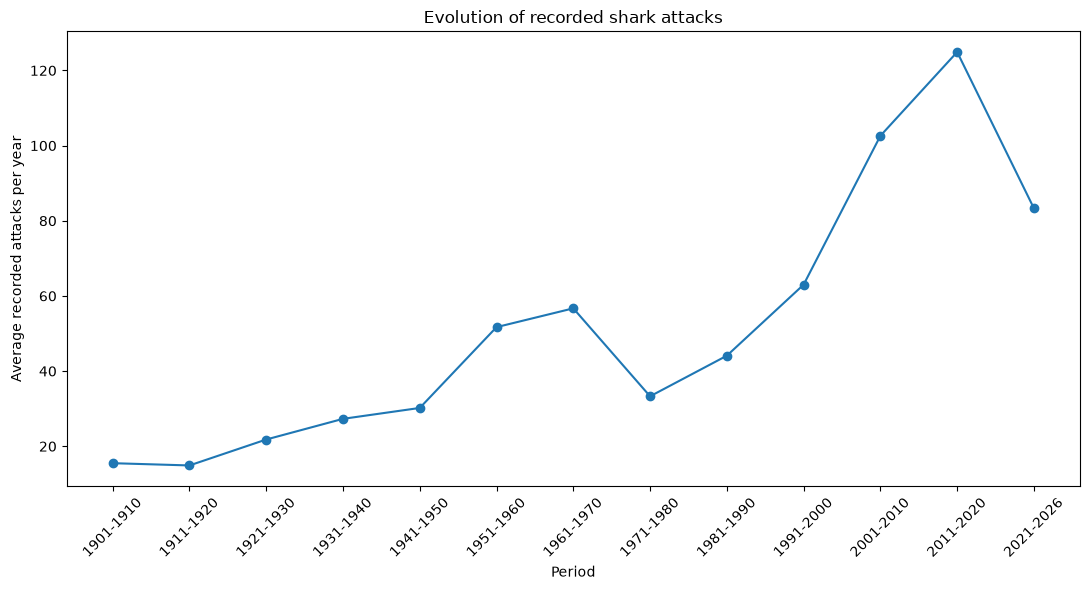

In [77]:
temporal_plot = temporal_analysis.loc[
    "1901-1910":"2021-2026"
].copy()

plt.figure(figsize=(11, 6))

plt.plot(
    temporal_plot.index,
    temporal_plot["Ataques_por_año"],
    marker="o"
)

plt.xlabel("Period")
plt.ylabel("Average recorded attacks per year")
plt.title("Evolution of recorded shark attacks")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 7.4 ¿Qué proporción de ataques son mortales?

Análisis de fatalidad

Finalmente analizamos la variable "Fatal Y/N" para estudiar la proporción de ataques registrados que fueron mortales.

Para calcular la tasa de fatalidad utilizamos únicamente los registros cuya fatalidad es conocida ("Y" o "N").

Los registros clasificados como "UNKNOWN" se excluyen de este cálculo, ya que no sabemos si el ataque fue mortal o no.

In [78]:
# Primero contamos Y, N y UNKNOWN

df["Fatal Y/N"].value_counts()

Fatal Y/N
N          4986
Y          1496
UNKNOWN     643
Name: count, dtype: Int64

La mayoría de los ataques registrados no fueron mortales.

# Calculamos la proporción global

In [79]:
fatal_known = df[
    df["Fatal Y/N"].isin(["Y", "N"])
]

fatal_counts = fatal_known["Fatal Y/N"].value_counts()

fatal_counts

Fatal Y/N
N    4986
Y    1496
Name: count, dtype: Int64

In [80]:
fatal_percentage = (
    fatal_counts / fatal_counts.sum() * 100
).round(1)

fatal_percentage

Fatal Y/N
N    76.9
Y    23.1
Name: count, dtype: Float64

Aproximadamente un 23 % de ataques mortales entre los casos con fatalidad conocida

In [81]:
fatal_summary = pd.DataFrame({
    "Cases": fatal_counts,
    "Percentage": fatal_percentage
})

fatal_summary

,Cases,Percentage
Fatal Y/N,,
N,4986,76.9
Y,1496,23.1


# 7.4 ¿Qué proporción de ataques son mortales? - Conclusión sobre la fatalidad global

Entre los ataques registrados cuya fatalidad es conocida, la mayoría fueron no mortales.

De un total de 6.482 casos con fatalidad conocida, 4.986 (76,9 %) fueron no mortales y 1.496 (23,1 %) fueron mortales.

Por tanto, aproximadamente 1 de cada 4 ataques registrados con desenlace conocido fue mortal.

Los registros clasificados como UNKNOWN no se incluyen en este cálculo, ya que no conocemos su desenlace.

# 7.4 ¿Qué proporción de ataques son mortales? - (Fatalidad por localización)

Además de calcular la proporción global de ataques mortales, analizamos si esta proporción cambia según la localización geográfica.

Para evitar resultados poco representativos, posteriormente excluiremos las localizaciones con muy pocos ataques conocidos.

In [82]:
fatal_by_location = (
    fatal_known
    .groupby(["Country", "State", "Fatal Y/N"])
    .size()
    .unstack(fill_value=0)
)

fatal_by_location.head()

,Fatal Y/N,N,Y
Country,State,,
ADMIRALTY ISLANDS,Manus Island,1,0
AFRICA,Unknown,0,1
ALGERIA,Unknown,0,1
AMERICAN SAMOA,Tutuila Island,0,3
ANDAMAN / NICOBAR ISLANDAS,Unknown,0,1


In [83]:
fatal_by_location["Total"] = (
    fatal_by_location["N"] +
    fatal_by_location["Y"]
)

In [ ]:
# Tasa de Fatalidad = Ataques mortales / ataques con fatalidad conocida × 100

fatal_by_location["Fatality Rate (%)"] = (
    fatal_by_location["Y"] /
    fatal_by_location["Total"] * 100
).round(1)

In [ ]:
# vamos a exigir al menos 20 ataques con fatalidad conocida

fatal_locations = fatal_by_location[
    fatal_by_location["Total"] >= 20
].copy()

In [ ]:
# Quitamos UNKNOWN

fatal_locations = fatal_locations.reset_index()

fatal_locations = fatal_locations[
    (fatal_locations["Country"] != "UNKNOWN") &
    (fatal_locations["State"].str.upper() != "UNKNOWN")
]

In [88]:
# ordenamos de mayor a menor tasa

fatal_locations = fatal_locations.sort_values(
    "Fatality Rate (%)",
    ascending=False
)

In [89]:
fatal_locations[
    [
        "Country",
        "State",
        "N",
        "Y",
        "Total",
        "Fatality Rate (%)"
    ]
].head(10)

Fatal Y/N,Country,State,N,Y,Total,Fatality Rate (%)
11,NEW CALEDONIA,South Province,11,9,20,45.0
10,BRAZIL,Pernambuco,46,30,76,39.5
5,AUSTRALIA,Torres Strait,47,23,70,32.9
15,SOUTH AFRICA,Kwazulu-Natal,128,49,177,27.7
3,AUSTRALIA,South Australia,86,30,116,25.9
2,AUSTRALIA,Queensland,244,83,327,25.4
0,AUSTRALIA,New South Wales,365,104,469,22.2
12,NEW ZEALAND,North Island,54,14,68,20.6
4,AUSTRALIA,Tasmania,30,7,37,18.9
16,SOUTH AFRICA,Western Cape Province,151,35,186,18.8


# 7.4 ¿Qué proporción de ataques son mortales? -  Conclusión de la fatalidad por localización

La proporción de ataques mortales presenta diferencias importantes según la localización geográfica.

Entre las regiones con al menos 20 ataques de fatalidad conocida, South Province (New Caledonia) presenta la mayor tasa de fatalidad, con un 45 %, seguida de Pernambuco (Brasil) con un 39,5 % y Torres Strait (Australia) con un 32,9 %.

Además, observamos que las zonas con mayor número de ataques registrados no son necesariamente las que presentan una mayor tasa de fatalidad. Por ejemplo, New South Wales registra 469 ataques con fatalidad conocida y presenta una tasa del 22,2 %, mientras que Pernambuco registra 76 casos y alcanza un 39,5 %.

Por tanto, los resultados muestran que la proporción de ataques mortales varía según la localización geográfica.

Para evitar resultados poco representativos, este análisis incluye únicamente localizaciones con al menos 20 ataques de fatalidad conocida.

# 7.4 ¿Qué proporción de ataques son mortales? - Visualización de la tasa de fatalidad por localización

Representamos las diez localizaciones con mayor tasa de fatalidad entre aquellas que cuentan con al menos 20 ataques de fatalidad conocida.

El filtro mínimo de casos permite reducir el efecto de porcentajes extremos provocados por localizaciones con muy pocos registros.

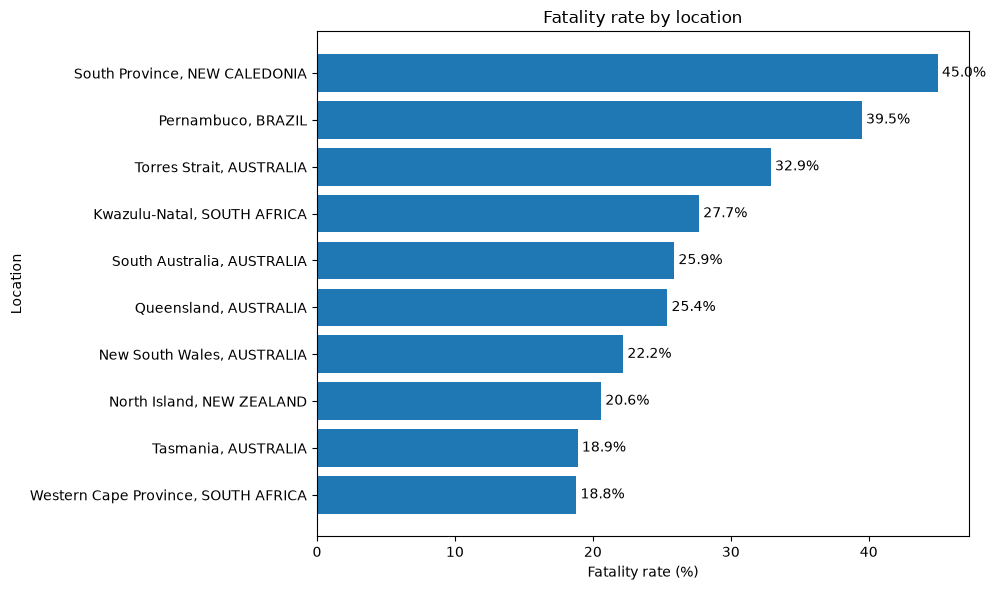

In [90]:
top_fatal_locations = fatal_locations.head(10).copy()

top_fatal_locations["Location"] = (
    top_fatal_locations["State"] +
    ", " +
    top_fatal_locations["Country"]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_fatal_locations["Location"][::-1],
    top_fatal_locations["Fatality Rate (%)"][::-1]
)

plt.xlabel("Fatality rate (%)")
plt.ylabel("Location")
plt.title("Fatality rate by location")

plt.bar_label(
    bars,
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()

# 7.4 ¿Qué proporción de ataques son mortales? - Comentario final

Visualmente podemos ver que la fatalidad varía bastante según la localización: desde el 45,0 % en South Province hasta el 18,8 % en Western Cape Province dentro de este Top 10 y aplicando vuestro filtro mínimo de 20 casos conocidos.

Además, destacaríamos que el 23,1 % de los ataques con desenlace conocido fueron mortales, y que las zonas con más ataques registrados no son necesariamente las que presentan mayor proporción de muertes.